# Gradient Validation

Demonstrates the end-to-end differentiability of the `gyaradax` solver by comparing JAX's reverse-mode autodiff (`jax.grad`) against numerical finite differences for a single time step.

In [1]:
import os
import sys

os.environ["CUDA_VISIBLE_DEVICES"] = "6"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "False"
sys.path.append("..")

In [2]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from gyaradax import load_geometry, gkstep_single, default_state
from gyaradax.params import GKParams
from gyaradax.plot_utils import plot_nd

# Enforce strict precision
jax.config.update("jax_enable_x64", True)

# Plotting style
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 14,
        "figure.titlesize": 16,
    }
)

cuBLAS < 13.2 (120804 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


## Setup

Load a reference geometry and initialize a random distribution function `df0`.

In [3]:
BASE = "/restricteddata/ukaea/gyrokinetics/raw/iteration_13"
geom = load_geometry(BASE)

shape = (
    len(geom["intvp"]),
    len(geom["intmu"]),
    len(geom["ints"]),
    len(geom["kxrh"]),
    len(geom["krho"]),
)
key = jax.random.PRNGKey(42)
df0_real = jax.random.normal(key, shape, dtype=jnp.float64)
df0_imag = jax.random.normal(jax.random.PRNGKey(43), shape, dtype=jnp.float64)
df0 = df0_real + 1j * df0_imag

params = GKParams(dt=0.01, naverage=40, non_linear=False)
state = default_state(nky=shape[-1])

## Gradients

In [4]:
def loss_fn(df_input):
    next_df, _, _ = gkstep_single(df_input, geom, params, state)
    # scalar real loss (energy)
    return jnp.sum(jnp.abs(next_df) ** 2)


loss_jitted = jax.jit(loss_fn)
grad_fn_jitted = jax.jit(jax.grad(loss_fn))

l_val = loss_jitted(df0)
analytical_grad = grad_fn_jitted(df0)

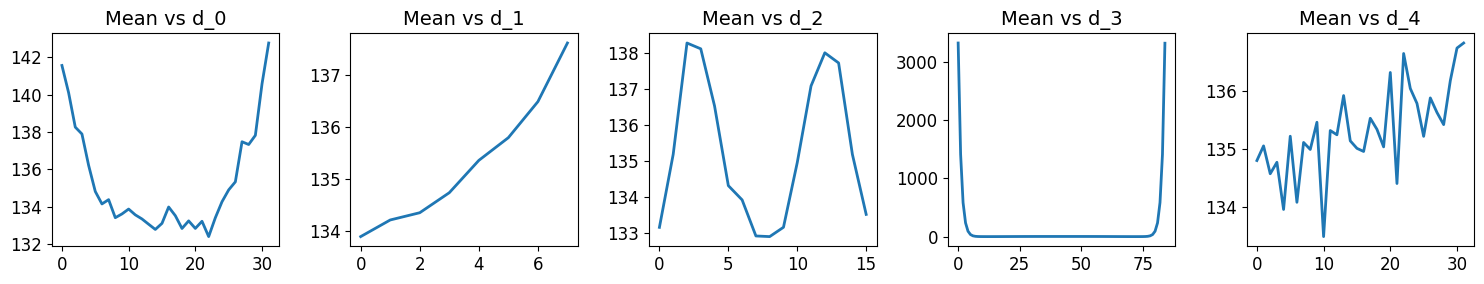

In [5]:
fig = plot_nd(analytical_grad)

## Finite Difference Validation

Validate gradient via central finite differences.

In [6]:
epsilon = 1e-5
num_samples = 200

# Select random indices across the 5D grid
np.random.seed(123)
flat_indices = np.random.choice(df0.size, num_samples, replace=False)
indices = np.unravel_index(flat_indices, df0.shape)

fd_grads_real = []
ad_grads_real = []

for i in range(num_samples):
    idx = tuple(ind[i] for ind in indices)

    # Base values
    val = df0[idx]

    # Perturb Real Part
    df_plus = df0.at[idx].set(val + epsilon)
    df_minus = df0.at[idx].set(val - epsilon)

    loss_plus = loss_jitted(df_plus)
    loss_minus = loss_jitted(df_minus)

    fd_grad_r = (loss_plus - loss_minus) / (2 * epsilon)

    # JAX grad convention for complex: df/dz = df/dx - i df/dy
    # Therefore, the real part of the AD gradient corresponds to the perturbation of the real part.
    ad_grad_r = jnp.real(analytical_grad[idx])

    fd_grads_real.append(float(fd_grad_r))
    ad_grads_real.append(float(ad_grad_r))

fd_grads_real = np.array(fd_grads_real)
ad_grads_real = np.array(ad_grads_real)

# Calculate relative error
rel_errors = np.abs(ad_grads_real - fd_grads_real) / (np.abs(ad_grads_real) + 1e-12)
max_err = np.max(rel_errors)
mean_err = np.mean(rel_errors)

print(f"Max Relative Error:  {max_err:.4f}")
print(f"Mean Relative Error: {mean_err:.4f}")

Max Relative Error:  1.2461
Mean Relative Error: 0.0335


## Alignment vs FD

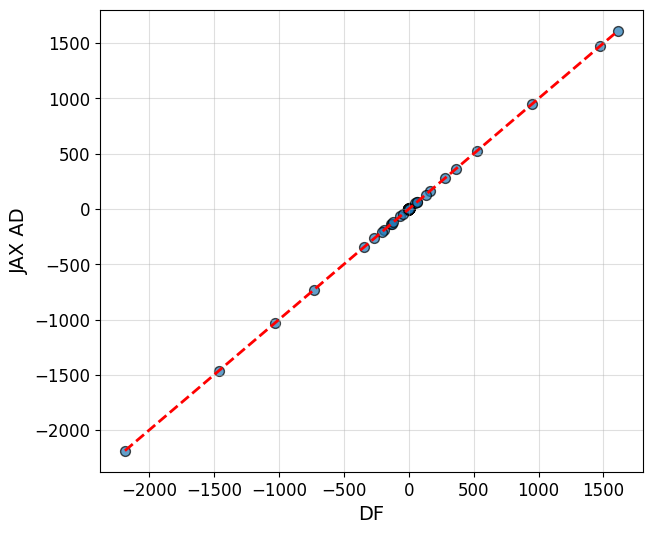

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(fd_grads_real, ad_grads_real, alpha=0.7, edgecolors="k", s=50)

min_val = min(np.min(fd_grads_real), np.min(ad_grads_real))
max_val = max(np.max(fd_grads_real), np.max(ad_grads_real))
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2)

plt.xlabel("DF")
plt.ylabel("JAX AD")
plt.grid(True, alpha=0.4)